# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Exploración y Curación de Datos**

*Edición 2025*

----

# Exploración de datos

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas

import seaborn
seaborn.set_context('talk')


### Cargar el Dataset




In [2]:
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [3]:
# ¿Cómo es la estructura del dataset?
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [4]:
# Estadísticas descriptivas de columnas numéricas
melb_df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [5]:
# ¿Qué columnas tienen valores faltantes?
missing_values = melb_df.isnull().sum()
missing_values[missing_values > 0]

Car               62
BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
dtype: int64

## Representación de los ejemplos

La tarea sobre la que nos centraremos es **estimar el precio de cada propiedad**, sabiendo el resto de sus características.

El primer paso de todo análisis es realizar una exploración de los datos y analizar las distribuciones de sus variables. Es decir, aplicar las herramientas que hemos estudiado durante la materia anterior, Análisis y Visualización de Datos. Por este motivo, no entraremos en detalles en esta notebook, sino que será parte de la ejercitación práctica.

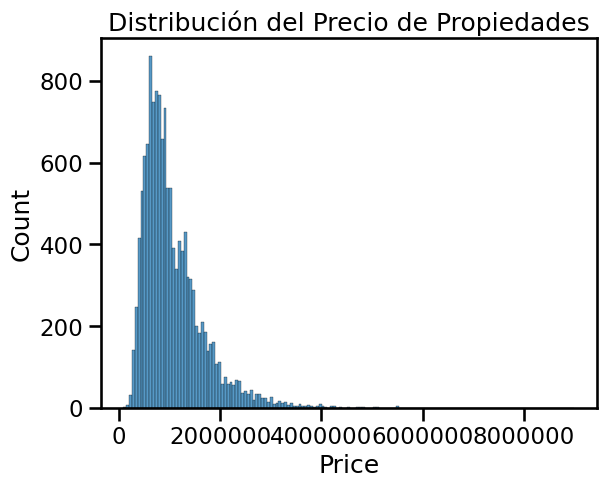

In [6]:
seaborn.histplot(melb_df.Price.dropna())
plt.ticklabel_format(style='plain', axis='x')
plt.title('Distribución del Precio de Propiedades')

plt.show()

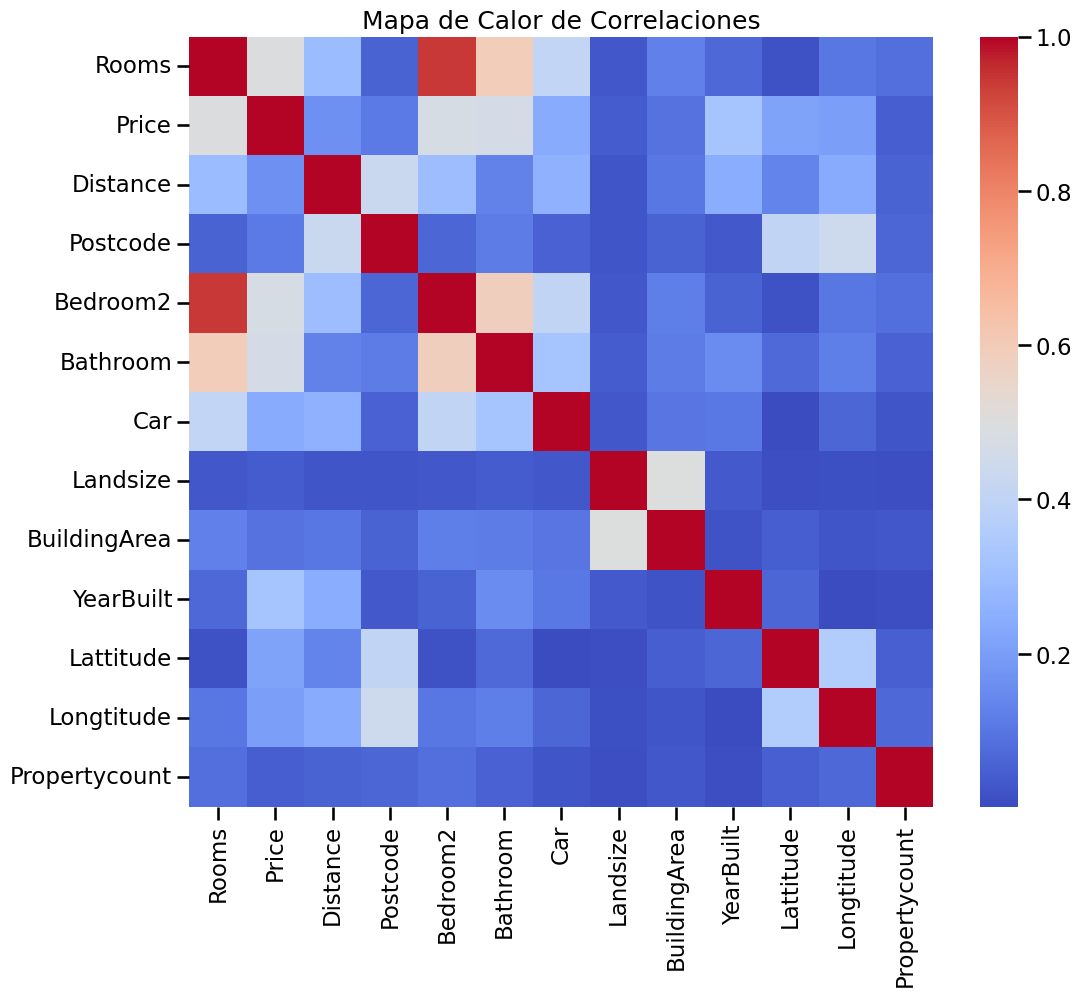

In [7]:
# Correlaciones entre variables numéricas
numeric_df = melb_df.select_dtypes(include=['number'])
corr = numeric_df.corr().abs()
plt.figure(figsize=(12, 10))
seaborn.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

In [8]:
# Correlación con SalePrice
target_corr = corr['Price'].sort_values(ascending=False)

# Mostrar top 10
print(target_corr.head(10))

Price         1.000000
Rooms         0.496634
Bedroom2      0.475951
Bathroom      0.467038
YearBuilt     0.323617
Car           0.238979
Lattitude     0.212934
Longtitude    0.203656
Distance      0.162522
Postcode      0.107867
Name: Price, dtype: float64


Luego de que tenemos una idea aproximada de la forma y el significado de cada una de las variables en nuestro conjunto de datos, tenemos que comenzar a pensar qué tan útiles son para mi tarea de predicción en particular.

# Bonus
## Fechas

Las fechas representan la variable *tiempo*, que no es trivial de representar en mi conjunto de datos.

* ¿Cómo afecta el tiempo al fenómeno que quiero estudiar?
* ¿Es importante de manera absoluta o de manera relativa?
* ¿Con qué nivel de precisión (o con qué escala) es relevante? ¿Años, días, minutos? ¿Importa la zona horaria?

Además de estas preguntas conceptuales, tenemos que tener en cuenta con qué tipo de datos (de Python) están representadas estas fechas:

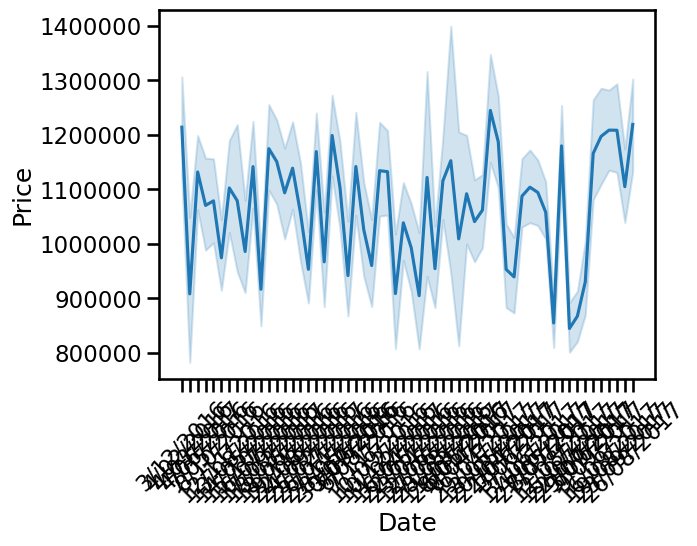

In [9]:
seaborn.lineplot(data=melb_df, x='Date', y='Price')
plt.xticks(rotation=45);
plt.ticklabel_format(style='plain', axis='y')

plt.show()

Al leer el dataset, las fechas fueron reconocidas como strings. Podemos cambiar el tipo de datos a `datetime`, que es una estructura de datos diseñada para trabajar con fechas hasta una precisión de milisegundos.

In [10]:
melb_df['date'] = pandas.to_datetime(melb_df.Date, format="%d/%m/%Y")

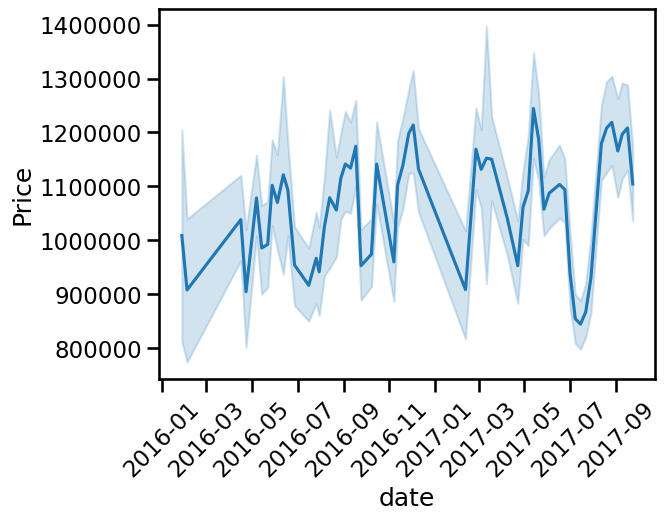

In [11]:
seaborn.lineplot(data=melb_df, x='date', y='Price')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

Podemos considerar que el día no es importante para este conjunto de datos, y que sólo está aportando ruido.

Para extraer sólo el mes de una fecha, aplicamos una función a cada fila.

In [12]:
melb_df['date_month'] = pandas.to_datetime(melb_df.date.dt.strftime('%Y-%m'))

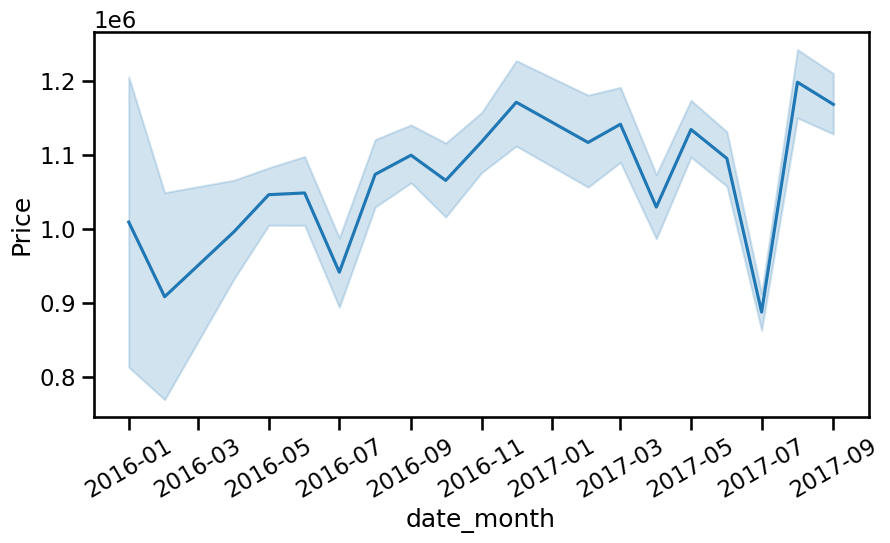

In [13]:
fig = plt.figure(figsize=(10, 5))
seaborn.lineplot(data=melb_df.sort_values('date_month'), x='date_month', y='Price')
plt.xticks(rotation=30);

## Ejercicio

En lugar de utilizar una precisión de meses, utilizar cuatrimestres para representar la fecha. Realizar una visualización del cambio de precios con respecto al año y al cuatrimestre.

Nota: investigue si existe una función en pandas para esto.

Para cuatrimestres, no existe una función de pandas que lo haga (como sí existe, por ejemplo, para trimestres). De todas formas, podemos crear esa función a mano.

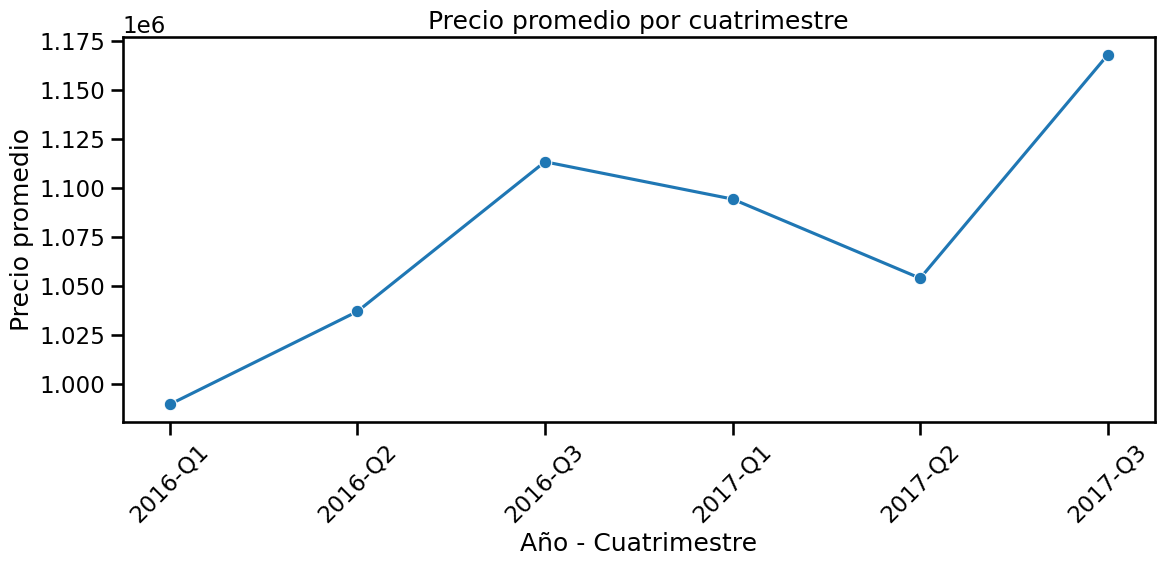

In [14]:
import pandas as pd
# Create a column of quadrimesters personalized
def get_quadrimester(month):
    if month <= 4:
        return 1
    elif month <= 8:
        return 2
    else:
        return 3

# column of the year
melb_df['year'] = melb_df['date'].dt.year
# column of the quadrimester
melb_df['quadrimester'] = melb_df['date'].dt.month.apply(get_quadrimester)
# both of them
melb_df['year_quadrimester'] = melb_df['year'].astype(str) + '-Q' + melb_df['quadrimester'].astype(str)

# Group by year and quadrimester and calculate mean price
grouped = melb_df.groupby('year_quadrimester')['Price'].mean().reset_index()

# Order
grouped['year_quadrimester'] = pd.Categorical(grouped['year_quadrimester'], 
                                               categories=sorted(grouped['year_quadrimester'], key=lambda x: (int(x[:4]), int(x[-1]))),
                                               ordered=True)

# Plot
plt.figure(figsize=(12, 6))
seaborn.lineplot(data=grouped, x='year_quadrimester', y='Price', marker='o')
plt.xticks(rotation=45)
plt.title('Precio promedio por cuatrimestre')
plt.xlabel('Año - Cuatrimestre')
plt.ylabel('Precio promedio')
plt.tight_layout()
plt.show()